Step 1: Load the cleaned data and set up plotting libraries.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

all_matches = pd.read_csv('data/processed/all_matches_clean.csv')
match_info = pd.read_csv('data/processed/match_info.csv')

print(all_matches.shape)
print(match_info.shape)

C:\Users\ramha.LAPTOP-AB00D4P2\AppData\Local\Temp\ipykernel_14464\420285849.py:5: DtypeWarning: Columns (0: season, 1: non_boundary, 2: fielder_3) have mixed types. Specify dtype option on import or set low_memory=False.
  all_matches = pd.read_csv('data/processed/all_matches_clean.csv')


(295732, 28)
(1243, 14)


Step 2: Build the innings-level summary table (total runs, wickets, balls per innings).

In [2]:
# total runs per delivery = runs off the bat + any extras
all_matches['total_runs'] = all_matches['runs_off_bat'] + all_matches['extras']

# a wicket happened if wicket_type is not empty
all_matches['is_wicket'] = all_matches['wicket_type'].notnull().astype(int)

innings_summary = all_matches.groupby(['match_id', 'season', 'innings', 'batting_team']).agg(
    total_runs=('total_runs', 'sum'),
    total_wickets=('is_wicket', 'sum'),
    balls_bowled=('ball', 'count')
).reset_index()

print(innings_summary.shape)
innings_summary.head(10)

(2518, 7)


,match_id,season,innings,batting_team,total_runs,total_wickets,balls_bowled
0,335982,2007/08,1,Kolkata Knight Riders,222,3,124
1,335982,2007/08,2,Royal Challengers Bengaluru,82,10,101
2,335983,2007/08,1,Chennai Super Kings,240,5,124
3,335983,2007/08,2,Punjab Kings,207,4,124
4,335984,2007/08,1,Rajasthan Royals,129,8,122
5,335984,2007/08,2,Delhi Capitals,132,1,97
6,335985,2007/08,1,Mumbai Indians,165,7,123
7,335985,2007/08,2,Royal Challengers Bengaluru,166,5,123
8,335986,2007/08,1,Deccan Chargers,110,10,118
9,335986,2007/08,2,Kolkata Knight Riders,112,5,122


Step 3: Sanity-check innings totals against realistic cricket ranges.

In [3]:
print(innings_summary['total_runs'].describe())
print(innings_summary['total_wickets'].describe())

count    2518.000000
mean      159.546465
std        38.790556
min         1.000000
25%       139.000000
50%       161.000000
75%       183.000000
max       287.000000
Name: total_runs, dtype: float64
count    2518.000000
mean        5.839952
std         2.514203
min         0.000000
25%         4.000000
50%         6.000000
75%         8.000000
max        10.000000
Name: total_wickets, dtype: float64


Step 4: List all_matches columns to investigate an unexpected extra column.

In [4]:
print(all_matches.columns.tolist())

['match_id', 'season', 'start_date', 'venue', 'innings', 'ball', 'actual_delivery', 'batting_team', 'bowling_team', 'striker', 'non_striker', 'bowler', 'runs_off_bat', 'extras', 'wides', 'noballs', 'byes', 'legbyes', 'penalty', 'non_boundary', 'wicket_type', 'player_dismissed', 'other_wicket_type', 'other_player_dismissed', 'fielder_1', 'fielder_2', 'fielder_3', 'delivery_seq', 'total_runs', 'is_wicket']


Step 5: Inspect the lowest-scoring innings for possible data anomalies.

In [5]:
lowest = innings_summary.sort_values('total_runs').head(5)
print(lowest)

# check what match_info says about this specific match
low_match_id = lowest.iloc[0]['match_id']
print(match_info[match_info['match_id'] == low_match_id][['match_id', 'season', 'venue', 'winner', 'team1', 'team2']])

      match_id   season  innings                 batting_team  total_runs  \
2444   1529281     2026        3         Lucknow Super Giants           1   
1574   1216512  2020/21        3          Sunrisers Hyderabad           2   
1534   1216493  2020/21        3                 Punjab Kings           2   
1034    829813     2015        2  Royal Challengers Bengaluru           2   
1535   1216493  2020/21        4               Delhi Capitals           3   

      total_wickets  balls_bowled  
2444              2             3  
1574              2             3  
1534              2             3  
1034              0             7  
1535              0             3  
     match_id season                                              venue  \
629   1529281   2026  "Bharat Ratna Shri Atal Bihari Vajpayee Ekana ...   

    winner                  team1                 team2  
629    NaN  Kolkata Knight Riders  Lucknow Super Giants  


Step 6: Check match_info for the suspicious 2026 match with a missing winner.

In [6]:
print(match_info[match_info['match_id'] == 1529281])

     match_id  balls_per_over     city        date                  event  \
629   1529281               6  Lucknow  2026/04/26  Indian Premier League   

    gender match_type season toss_decision           toss_winner  \
629   male        T20   2026         field  Lucknow Super Giants   

                                                 venue winner  \
629  "Bharat Ratna Shri Atal Bihari Vajpayee Ekana ...    NaN   

                     team1                 team2  
629  Kolkata Knight Riders  Lucknow Super Giants  


Step 7: Filter out Super Over innings, keeping only normal innings 1 and 2.

In [7]:
main_innings = innings_summary[innings_summary['innings'].isin([1, 2])].copy()
print(main_innings.shape)
print(main_innings['total_runs'].describe())

(2484, 7)
count    2484.000000
mean      161.603462
std        34.806944
min         2.000000
25%       141.000000
50%       162.000000
75%       184.000000
max       287.000000
Name: total_runs, dtype: float64


Step 8: Re-fix the season column's mixed data type after reloading.

In [8]:
all_matches['season'] = all_matches['season'].astype(str)

Step 9: Calculate and plot average IPL innings score by season.

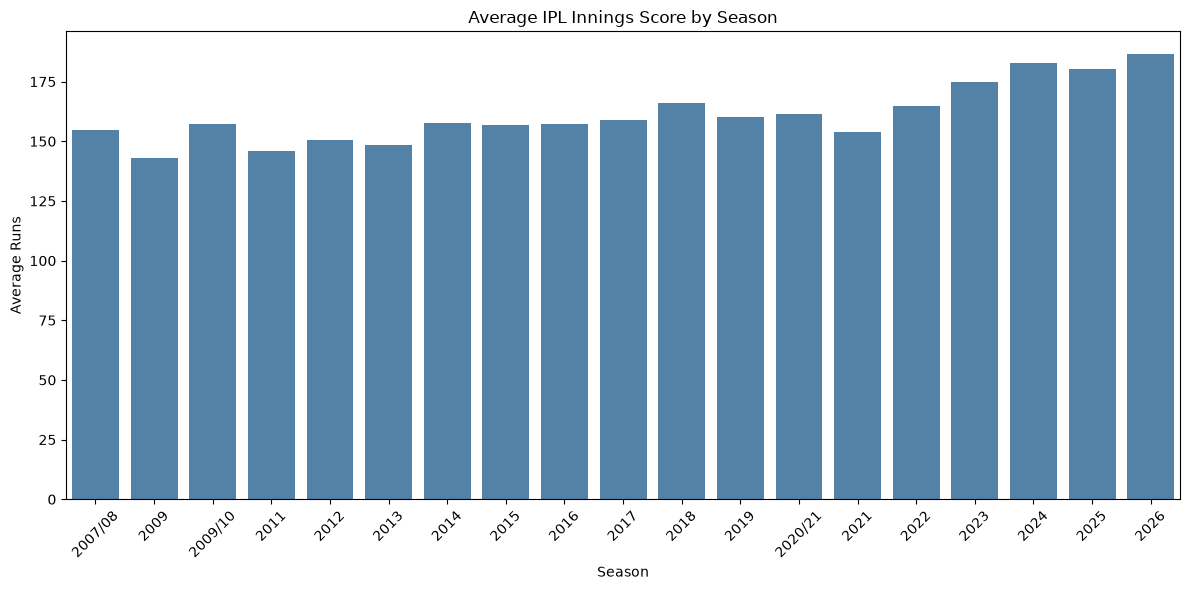

In [9]:
main_innings['season'] = main_innings['season'].astype(str)

season_avg = main_innings.groupby('season')['total_runs'].mean().reset_index()
season_avg = season_avg.sort_values('season')

plt.figure(figsize=(12, 6))
sns.barplot(data=season_avg, x='season', y='total_runs', color='steelblue')
plt.title('Average IPL Innings Score by Season')
plt.xlabel('Season')
plt.ylabel('Average Runs')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Step 10: Calculate and plot overall run rate by season.

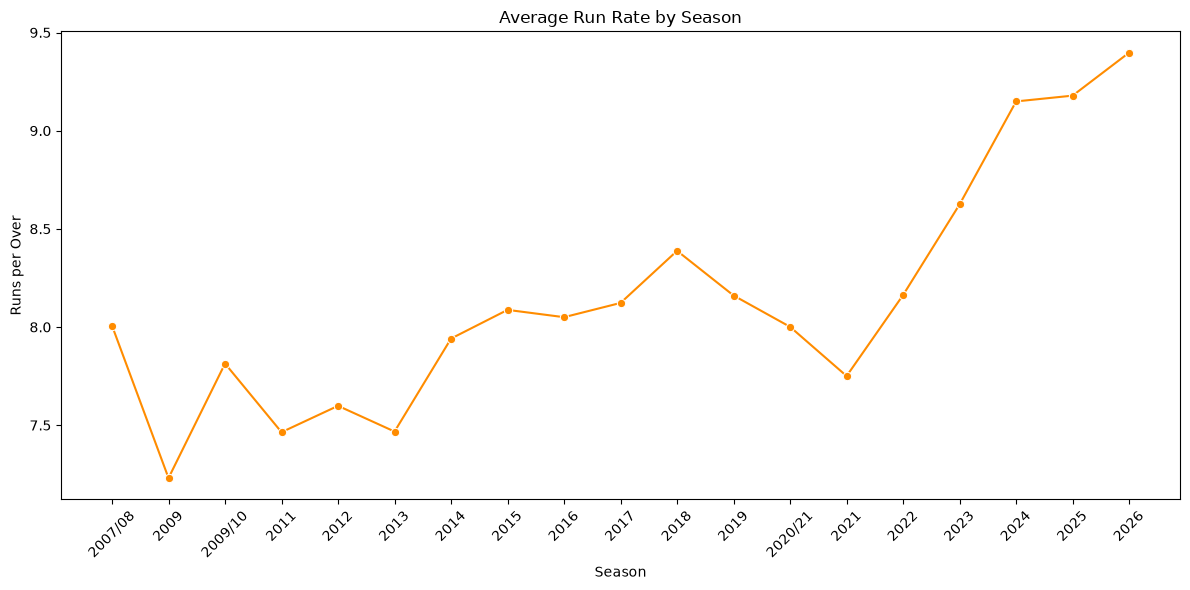

In [10]:
main_innings['run_rate'] = (main_innings['total_runs'] / main_innings['balls_bowled']) * 6

rr_by_season = main_innings.groupby('season')['run_rate'].mean().reset_index()
rr_by_season['season'] = rr_by_season['season'].astype(str)
rr_by_season = rr_by_season.sort_values('season')

plt.figure(figsize=(12, 6))
sns.lineplot(data=rr_by_season, x='season', y='run_rate', marker='o', color='darkorange')
plt.title('Average Run Rate by Season')
plt.xlabel('Season')
plt.ylabel('Runs per Over')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Step 11: Split deliveries into powerplay/middle/death phases and plot run rate by phase.

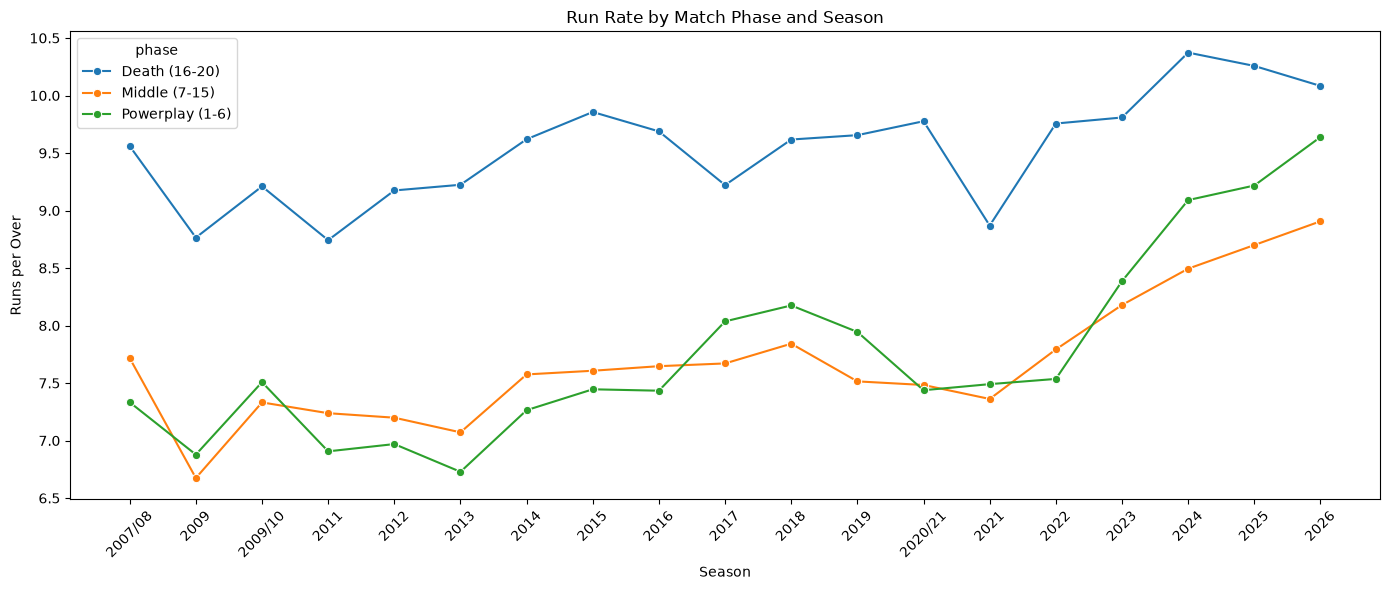

In [11]:
all_matches['over_num'] = all_matches['ball'].astype(str).str.split('.').str[0].astype(int)

def phase(over):
    if over < 6:
        return 'Powerplay (1-6)'
    elif over < 15:
        return 'Middle (7-15)'
    else:
        return 'Death (16-20)'

all_matches['phase'] = all_matches['over_num'].apply(phase)

phase_scoring = all_matches.groupby(['season', 'phase'])['total_runs'].sum().reset_index()
phase_balls = all_matches.groupby(['season', 'phase']).size().reset_index(name='balls')
phase_summary = phase_scoring.merge(phase_balls, on=['season', 'phase'])
phase_summary['run_rate'] = (phase_summary['run_rate'] if 'run_rate' in phase_summary else phase_summary['total_runs'] / phase_summary['balls']) * 6
phase_summary['season'] = phase_summary['season'].astype(str)

plt.figure(figsize=(14, 6))
sns.lineplot(data=phase_summary.sort_values('season'), x='season', y='run_rate', hue='phase', marker='o')
plt.title('Run Rate by Match Phase and Season')
plt.xlabel('Season')
plt.ylabel('Runs per Over')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Step 12: Calculate and plot sixes and dot-ball percentage by season.

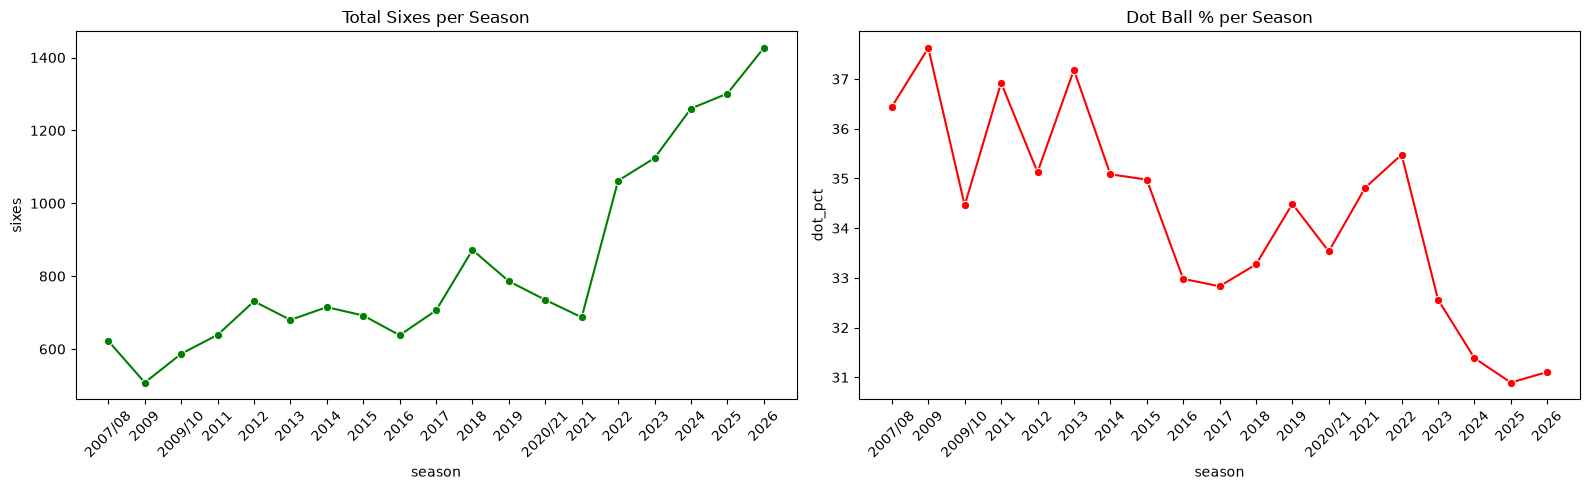

In [12]:
all_matches['is_four'] = ((all_matches['runs_off_bat'] == 4) & (all_matches['non_boundary'] != 1)).astype(int)
all_matches['is_six'] = ((all_matches['runs_off_bat'] == 6) & (all_matches['non_boundary'] != 1)).astype(int)
all_matches['is_dot'] = (all_matches['total_runs'] == 0).astype(int)

boundary_summary = all_matches.groupby('season').agg(
    fours=('is_four', 'sum'),
    sixes=('is_six', 'sum'),
    dot_balls=('is_dot', 'sum'),
    total_balls=('is_dot', 'count')
).reset_index()

boundary_summary['dot_pct'] = (boundary_summary['dot_balls'] / boundary_summary['total_balls']) * 100
boundary_summary['season'] = boundary_summary['season'].astype(str)
boundary_summary = boundary_summary.sort_values('season')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.lineplot(data=boundary_summary, x='season', y='sixes', marker='o', ax=axes[0], color='green')
axes[0].set_title('Total Sixes per Season')
axes[0].tick_params(axis='x', rotation=45)

sns.lineplot(data=boundary_summary, x='season', y='dot_pct', marker='o', ax=axes[1], color='red')
axes[1].set_title('Dot Ball % per Season')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()